<a href="https://colab.research.google.com/github/PanconquesoHH/Laboratorios-ia/blob/main/LAB2_PyTorch_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio de programación: regresión lineal múltiple con PyTorch

Adaptación sencilla del LAB2 siguiendo el orden del cuadernillo `02 reg_lin_mul_01`.
El objetivo es calcular los coeficientes para predecir el salario `wage_eur` de los jugadores de FIFA mediante **descenso por el gradiente** y **ecuación normal**.

Se utilizan todos los registros del CSV para ambos cálculos.

In [ ]:
import os
import pandas as pd
import torch
from matplotlib import pyplot

torch.set_num_threads(2)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 1. Cargar los datos
Cambia la ruta si tu archivo tiene otro nombre o está en otra carpeta.
`y` contiene los salarios y `X_df` contiene las características de los jugadores.

In [ ]:
dataset = '/content/drive/MyDrive/FIFA 22/fifa_players.csv'
# Si lo guardaste con el nombre adjunto, usa fifa_players(1).csv.
print('Archivo a usar:', os.path.abspath(dataset))

df = pd.read_csv(dataset)
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# El CSV adjunto tiene salarios numéricos completos.
y = torch.tensor(df['wage_eur'].values, dtype=torch.float64)
X_df = df.drop(columns=['wage_eur']).copy()

print('Número de muestras:', len(y))
print('Número de características:', X_df.shape[1])

Archivo a usar: fifa_players(1).csv
Número de muestras: 19178
Número de características: 28


### Convertir los textos a números
La nacionalidad viene como texto. Le asignamos un número a cada categoría, como en el LAB2, para poder realizar los cálculos. Esta es una codificación sencilla; los números asignados no representan un orden real entre nacionalidades.

In [ ]:
for col in X_df.columns:
    if X_df[col].dtype == 'object':
        X_df[col], categorias = pd.factorize(X_df[col].fillna('Missing'), sort=True)
    else:
        X_df[col] = X_df[col].fillna(X_df[col].mean())

# Convertimos las características a un tensor de PyTorch.
X = torch.tensor(X_df.values, dtype=torch.float64)
m = X.shape[0]

# Guardamos los datos sin normalizar para la ecuación normal.
X_original = X.clone()

print('Tamaño de X:', X.shape)
print('Tamaño de y:', y.shape)
print('Primeras cinco filas de X:')
print(X[:5])

Tamaño de X: torch.Size([19178, 28])
Tamaño de y: torch.Size([19178])
Primeras cinco filas de X:
tensor([[ 34., 170.,  72.,   6.,  93.,  93.,  85.,  95.,  70.,  91.,  88.,  96.,
          93.,  94.,  91.,  96.,  91.,  80.,  91.,  94.,  95.,  35.,  24.,   6.,
          11.,  15.,  14.,   8.],
        [ 32., 185.,  81., 123.,  92.,  92.,  71.,  95.,  90.,  85.,  89.,  85.,
          79.,  85.,  70.,  88.,  77.,  79.,  77.,  93.,  82.,  42.,  19.,  15.,
           6.,  12.,   8.,  10.],
        [ 36., 187.,  83., 124.,  91.,  91.,  87.,  95.,  90.,  80.,  86.,  88.,
          81.,  84.,  77.,  88.,  85.,  88.,  86.,  94.,  74.,  32.,  24.,   7.,
          11.,  15.,  14.,  11.],
        [ 29., 175.,  68.,  20.,  91.,  91.,  85.,  83.,  63.,  86.,  86.,  95.,
          88.,  87.,  81.,  95.,  93.,  89.,  96.,  89.,  84.,  32.,  29.,   9.,
           9.,  15.,  15.,  11.],
        [ 30., 181.,  70.,  13.,  91.,  91.,  94.,  82.,  55.,  94.,  82.,  88.,
          85.,  83.,  93.,  91.,  76.,

## 2. Normalización de características
Las características tienen distintas escalas. Para facilitar el descenso por el gradiente, restamos la media y dividimos entre la desviación estándar:

$$X_{norm}=\frac{X-\mu}{\sigma}$$

Guardamos `mu` y `sigma` para normalizar también los datos al hacer una predicción.

In [ ]:
def featureNormalize(X):
    mu = torch.mean(X, dim=0)
    sigma = torch.std(X, dim=0, unbiased=False)
    sigma[sigma == 0] = 1  # Evita dividir entre cero.
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = featureNormalize(X)

print('Media calculada:', mu)
print('Desviación estándar calculada:', sigma)
print('Primeras cinco filas normalizadas:')
print(X_norm[:5])

Media calculada: tensor([ 25.2012, 181.2881,  74.9305,  79.5647,  65.7602,  71.0764,  49.5680,
         45.8902,  51.7733,  58.8607,  42.4584,  55.6611,  47.2634,  42.2371,
         53.0601,  58.4693,  64.6577,  64.7206,  63.5059,  61.4369,  64.0783,
         48.0324,  45.8908,  16.3973,  16.1872,  16.0491,  16.2217,  16.4847],
       dtype=torch.float64)
Desviación estándar calculada: tensor([ 4.7461,  6.8620,  7.0654, 48.5542,  6.8823,  6.0892, 18.0305, 19.7177,
        17.2890, 14.4885, 17.6518, 18.7814, 18.1782, 17.1739, 15.0244, 16.6578,
        15.1645, 14.9610, 14.8601,  9.0423, 14.3276, 21.2273, 20.7495, 17.5607,
        16.8287, 16.5552, 17.0478, 17.8728], dtype=torch.float64)
Primeras cinco filas normalizadas:
tensor([[ 1.8539, -1.6450, -0.4148, -1.5151,  3.9580,  3.6004,  1.9651,  2.4906,
          1.0542,  2.2183,  2.5800,  2.1478,  2.5160,  3.0141,  2.5252,  2.2530,
          1.7371,  1.0213,  1.8502,  3.6012,  2.1582, -0.6139, -1.0550, -0.5921,
         -0.3082, -0.0634, 

Añadimos la columna de unos para el término independiente `theta[0]`, igual que en el ejemplo.

In [ ]:
X = torch.cat([torch.ones((m, 1), dtype=torch.float64), X_norm], dim=1)
print('Tamaño de X con la columna de unos:', X.shape)

Tamaño de X con la columna de unos: torch.Size([19178, 29])


## 3. Descenso por el gradiente
La predicción se calcula con `X @ theta`. El símbolo `@` realiza la multiplicación matricial.
El costo se calcula igual que en el ejemplo:

$$J(\theta)=\frac{1}{2m}\sum_{i=1}^{m}(\hat{y}_i-y_i)^2$$

In [ ]:
def computeCostMulti(X, y, theta):
    m = y.shape[0]
    J = torch.sum((X @ theta - y) ** 2) / (2 * m)
    return J

PyTorch calcula los gradientes con `backward()`. Después actualizamos `theta` usando `alpha`, como en el cuadernillo original.

- `requires_grad_(True)` activa el cálculo de derivadas para `theta`.
- `torch.no_grad()` permite actualizar sus valores sin calcular derivadas de esa actualización.
- `theta.grad.zero_()` borra las derivadas antes de la siguiente iteración.

In [ ]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    theta = theta.clone().detach().requires_grad_(True)
    J_history = []

    for i in range(num_iters):
        J = computeCostMulti(X, y, theta)
        J.backward()  # Calcula las derivadas del costo.

        with torch.no_grad():
            theta -= alpha * theta.grad
            J_history.append(computeCostMulti(X, y, theta).item())

        theta.grad.zero_()

    return theta.detach(), J_history

Theta calculado por el descenso por el gradiente:
tensor([ 9017.9894, -1377.1542,  1152.4673,  -215.6674,  -128.3955,  9823.6770,
         2693.5761,   611.1506,  -547.8033,  -483.5292,  -904.6224,  1613.0417,
         -333.8551,   884.7507,  -195.9166,   772.4768, -2303.0018, -1120.7146,
          321.9504,  -986.6667,  1820.2196,  1760.9232,   253.0348,  -968.6276,
         -272.6892,  -129.6500,   707.1304, -1894.1903,  -425.9351],
       dtype=torch.float64)


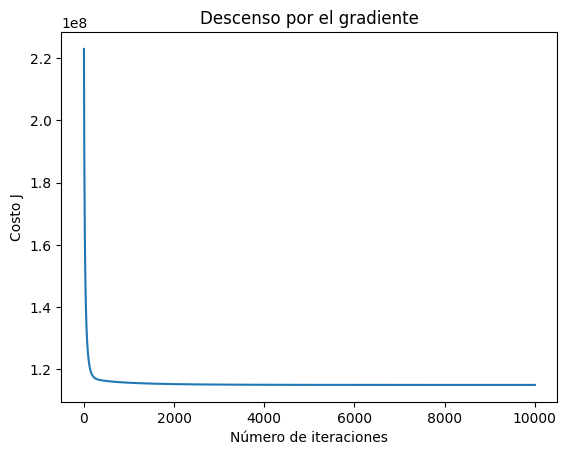

In [ ]:
alpha = 0.01
num_iters = 10000

theta = torch.zeros(X.shape[1], dtype=torch.float64)
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

pyplot.plot(range(1, num_iters + 1), J_history)
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Descenso por el gradiente')
pyplot.show()

print('Theta calculado por el descenso por el gradiente:')
print(theta)

### Predecir el salario de un jugador
Utilizamos el primer jugador del CSV como ejemplo. Su fila debe normalizarse con las mismas medias y desviaciones usadas antes.

In [ ]:
X_array = X_original[0].clone()
X_array = (X_array - mu) / sigma
X_array = torch.cat([torch.ones(1, dtype=torch.float64), X_array])

price = torch.dot(X_array, theta).item()
print(f'Salario predicho con descenso por el gradiente: €{price:,.2f}')
print(f'Salario real del primer jugador: €{y[0].item():,.2f}')

Salario predicho con descenso por el gradiente: €60,978.95
Salario real del primer jugador: €320,000.00


## 4. Ecuación normal
En el cuadernillo de ejemplo se usa:

$$\theta=(X^T X)^{-1}X^T y$$

Este método calcula los coeficientes directamente, sin iteraciones ni `alpha`.
Usamos los datos originales y añadimos la columna de unos; aquí no normalizamos.

Para evitar que el cálculo falle si una matriz no tiene inversa, usamos `torch.linalg.pinv(X) @ y`. Es la solución de mínimos cuadrados mediante pseudoinversa, equivalente a la ecuación normal cuando $X^T X$ es invertible.

In [ ]:
X_normal = torch.cat([
    torch.ones((m, 1), dtype=torch.float64),
    X_original
], dim=1)

def normalEqn(X, y):
    theta = torch.linalg.pinv(X) @ y
    return theta

theta_normal = normalEqn(X_normal, y)

print('Theta calculado por la solución analítica:')
print(theta_normal)

Theta calculado por la solución analítica:
tensor([-1.4065e+05, -2.9361e+02,  1.6814e+02, -3.0907e+01, -2.6302e+00,
         1.4360e+03,  4.3872e+02,  3.3397e+01, -2.8100e+01, -2.8285e+01,
        -6.2006e+01,  9.1482e+01, -1.4906e+01,  4.8593e+01, -1.1403e+01,
         5.1573e+01, -1.4348e+02, -7.4347e+01,  2.1368e+01, -6.6433e+01,
         1.9990e+02,  1.2322e+02,  1.5391e+01, -5.0454e+01, -1.5739e+01,
        -7.2099e+00,  4.5811e+01, -1.1549e+02, -2.5056e+01],
       dtype=torch.float64)


In [ ]:
# El mismo jugador, esta vez sin normalizar sus características.
X_array = X_normal[0]
price = torch.dot(X_array, theta_normal).item()

print(f'Salario predicho con la solución analítica: €{price:,.2f}')
print(f'Salario real del primer jugador: €{y[0].item():,.2f}')

Salario predicho con la solución analítica: €61,005.86
Salario real del primer jugador: €320,000.00


El descenso por el gradiente ajusta los coeficientes poco a poco; la solución analítica los calcula directamente.
Los coeficientes de ambos métodos están en escalas diferentes porque solo normalizamos las características para el descenso.
Las predicciones del primer jugador son ejemplos de uso del modelo sobre los datos utilizados en el cálculo.